In [ ]:
# Import necessary libraries
from sklearn.datasets import load_iris          # Load the Iris dataset
from sklearn.decomposition import PCA            # Principal Component Analysis (for 2D visualization)
from sklearn.cluster import AgglomerativeClustering  # Hierarchical clustering algorithm
from sklearn.metrics import silhouette_score     # Evaluate clustering quality
from scipy.cluster.hierarchy import dendrogram, linkage  # Tools to create dendrograms
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = iris.data                                     # Feature matrix (150 samples, 4 features)
y = iris.target                                   # Ground truth labels for reference
target_names = iris.target_names

In [ ]:
# Generate linkage matrix for dendrogram (for visualization of cluster merging)
linked = linkage(X, method='ward') # Ward minimizes variance within clusters

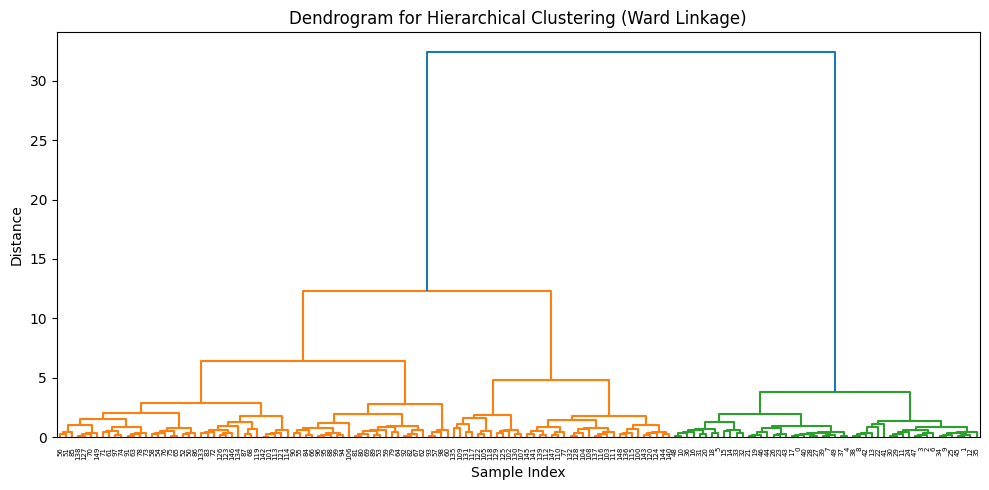

In [ ]:
# Plot the dendrogram to visualize how clusters are merged
plt.figure(figsize=(10, 5))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Dendrogram for Hierarchical Clustering (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)   # Transformed data for plotting

In [ ]:
# Apply Agglomerative Hierarchical Clustering
model = AgglomerativeClustering(
    n_clusters=3,              # Number of clusters to find
    metric='euclidean',        # Distance metric
    linkage='ward'              # Linkage criterion (minimize variance)
)
cluster_labels = model.fit_predict(X)   # Predict cluster labels

In [ ]:
# Create DataFrame for plotting
df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df['Cluster'] = cluster_labels
df['True Label'] = y

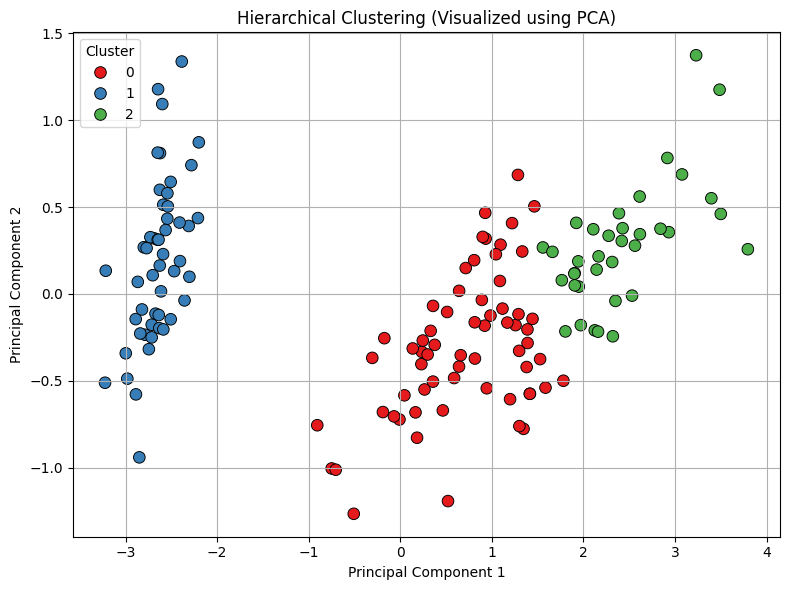

In [ ]:
# Plot the clustering result
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='Cluster',
    palette='Set1', s=70, edgecolor='k'
)
plt.title("Hierarchical Clustering (Visualized using PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

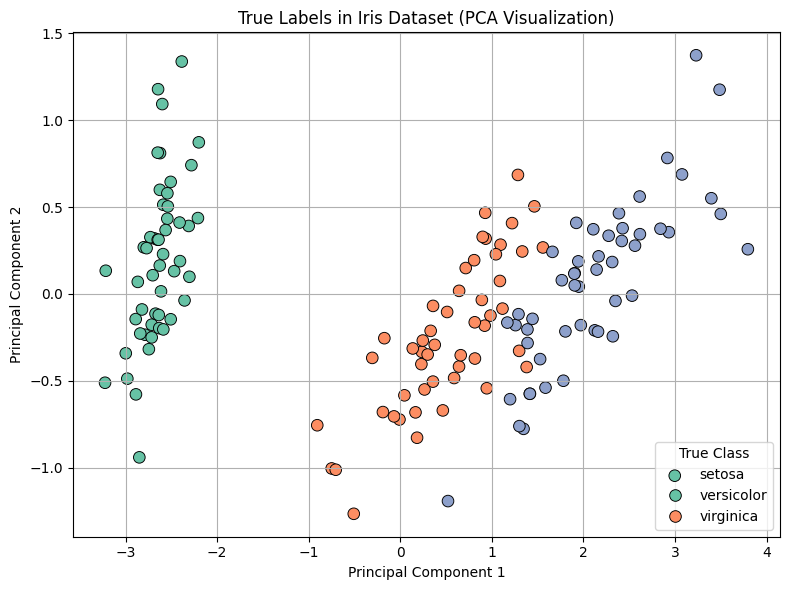

In [ ]:
# Plot the true class labels for comparison
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='True Label',
    palette='Set2', s=70, edgecolor='k'
)
plt.title("True Labels in Iris Dataset (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="True Class", labels=target_names)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Compute silhouette score for the hierarchical clustering
sil_score = silhouette_score(X, cluster_labels)
print(f"Silhouette Score for Hierarchical Clustering (k=3): {sil_score:.3f}")

Silhouette Score for Hierarchical Clustering (k=3): 0.554
